# AI 水文学入门 101：如何用人工智能预测洪水？

欢迎来到这个令人兴奋的教学 Notebook！在这里，我们将探索如何利用人工智能（AI）来预测世界上那些从未被测量过的河流的洪水。

**适合人群**：大一新生，具备基础高等数学知识，但对 AI 和水文学不太熟悉。

**学习目标**：
1. 理解什么是"未测流域"及其重要性
2. 了解 AI 如何通过静态特征（GNN）和动态天气（LSTM）预测河流流量
3. 可视化降雨和流量的时间关系
4. 动手训练一个简化的 AI 模型
5. 见证 AI 预测未知河流的能力

---

## 📚 目录
1. [引言：如果不去测量，我们如何知道河流的流量？](#section1)
2. [数据可视化：河流的"心电图"](#section2)
3. [解剖 AI 大脑：GNN 与 LSTM](#section3)
4. [动手实验：训练一个"宝宝"模型](#section4)
5. [见证奇迹：预测未知的河流](#section5)
6. [总结与思考](#section6)

---
<a id='section1'></a>
## 1. 引言：如果不去测量，我们如何知道河流的流量？

### 什么是"未测流域" (Ungauged Watersheds)？

想象一下，全球有数百万条河流，但只有很少一部分（大约 1%）安装了流量测量设备（称为"水文站"）。那么，对于其他 99% 的河流，我们如何预测它们的洪水风险呢？

这就是**未测流域**的挑战！

### 传统方法 vs. AI 方法

| 方法 | 类比 | 局限性 |
|------|------|--------|
| **传统水文模型** | 像通过看病历来了解一个人的健康状况 | 需要大量历史数据，对未测流域无效 |
| **AI 深度学习** | 像通过看一个人的长相（静态特征）和最近几天的饮食（动态天气）来预测他的健康状况 | 可以从有数据的河流学习，然后推广到无数据的河流 |

### 核心思想

AI 模型通过两种方式"理解"河流：
- **静态特征（GNN）**：河流的"身份证"——坡度、土壤类型、森林覆盖率等
- **动态特征（LSTM）**：河流的"记忆"——过去几个月的降雨、温度等

让我们先加载一些库和数据！

In [1]:
# 导入必需的库
import sys
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（可选，如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ===== 检查必需的依赖 =====
print("📦 检查必需的依赖包...\n")
required_packages = {
    'h5netcdf': 'h5netcdf',
    'xarray': 'xarray',
    'torch': 'torch',
    'torch_geometric': 'torch_geometric'
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} 已安装")
    except ImportError:
        print(f"✗ {package_name} 未安装")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️ 缺少必需的包: {', '.join(missing_packages)}")
    print(f"\n请运行以下命令安装:")
    print(f"  pip install {' '.join(missing_packages)}")
    print(f"\n或者使用 conda:")
    print(f"  conda install -c conda-forge {' '.join(missing_packages)}")

# ===== 路径配置 =====
print("\n" + "="*60)
print("配置 Python 路径...")
print("="*60)

# 获取当前 notebook 的目录
notebooks_dir = os.getcwd()
print(f"🔍 当前工作目录: {notebooks_dir}")

# 检查是否在 notebooks 目录中
if not notebooks_dir.endswith('notebooks'):
    # 如果不在 notebooks 目录中，尝试找到它
    if os.path.exists(os.path.join(notebooks_dir, 'notebooks')):
        notebooks_dir = os.path.join(notebooks_dir, 'notebooks')
    else:
        print("⚠️ 警告: 无法确认当前在 notebooks 目录中")

# 获取项目根目录
project_root = os.path.dirname(notebooks_dir)

# 确保后端和模型路径在 sys.path 中（使用 insert(0) 确保优先级）
if notebooks_dir not in sys.path:
    sys.path.insert(0, notebooks_dir)  # 添加 notebooks 目录，用于导入 backend
if project_root not in sys.path:
    sys.path.insert(0, project_root)  # 添加项目根目录，用于导入 models

print(f"✅ 项目根目录: {project_root}")
print(f"✅ Notebooks 目录: {notebooks_dir}")
print(f"✅ sys.path 已配置正确")

# 验证必要的目录存在
backend_dir = os.path.join(notebooks_dir, 'backend')
models_dir = os.path.join(project_root, 'models')

backend_exists = os.path.isdir(backend_dir)
models_exists = os.path.isdir(models_dir)
backend_init = os.path.isfile(os.path.join(backend_dir, '__init__.py'))

print(f"\n✓ backend 目录存在: {backend_exists}")
print(f"✓ backend/__init__.py 存在: {backend_init}")
print(f"✓ models 目录存在: {models_exists}")

if not backend_init:
    print("\n⚠️  警告: backend/__init__.py 不存在，正在创建...")
    try:
        with open(os.path.join(backend_dir, '__init__.py'), 'w') as f:
            f.write('"""Backend utilities for hydrology predictions."""\n')
        print("✅ backend/__init__.py 已创建")
    except Exception as e:
        print(f"❌ 无法创建 backend/__init__.py: {e}")

📦 检查必需的依赖包...

✓ h5netcdf 已安装
✓ h5netcdf 已安装
✓ xarray 已安装
✓ xarray 已安装
✓ torch 已安装
✓ torch 已安装
✓ torch_geometric 已安装

配置 Python 路径...
🔍 当前工作目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ 项目根目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds
✅ Notebooks 目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ sys.path 已配置正确

✓ backend 目录存在: True
✓ backend/__init__.py 存在: True
✓ models 目录存在: True
✓ torch_geometric 已安装

配置 Python 路径...
🔍 当前工作目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ 项目根目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds
✅ Notebooks 目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ sys.path 已配置正确

✓ backend 目录存在: True
✓ backend/__init__.py 存在: True
✓ models 目录存在: True


In [2]:
# 自动安装缺少的依赖包（可选）
# 如果上面检测到缺少的包，取消注释下面的代码来自动安装

# Uncomment to auto-install missing packages:
# import subprocess
# import sys
# 
# missing_packages = ['h5netcdf', 'xarray', 'torch', 'torch_geometric']
# for package in missing_packages:
#     try:
#         __import__(package.replace('-', '_'))
#     except ImportError:
#         print(f"Installing {package}...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Or run this manually in your terminal:
# pip install h5netcdf xarray torch scikit-learn tqdm
# conda install -c conda-forge torch_geometric (for PyTorch Geometric)

### 可视化：世界上有多少河流被测量？

让我们加载全球水文站数据，看看有多少河流有历史记录。

In [3]:
# 尝试加载 GRDC（全球径流数据中心）数据
print("🔄 尝试加载 GRDC（全球径流数据中心）数据...\n")

try:
    # First check if h5netcdf is available
    try:
        import h5netcdf
    except ImportError:
        raise ImportError(
            "h5netcdf 未安装。请运行:\n"
            "  pip install h5netcdf\n"
            "或:\n"
            "  conda install -c conda-forge h5netcdf"
        )
    
    print("📦 正在导入 backend.loading_utils...")
    from backend import loading_utils
    
    print("📊 正在加载 GRDC 数据...")
    grdc_data = loading_utils.load_grdc_data()
    
    if grdc_data is not None:
        num_gauges = len(grdc_data.gauge_id)
        print(f"✅ 数据加载成功！")
        print(f"🌍 全球共有 {num_gauges} 个水文站有历史数据")
        print(f"📊 这只占全球河流的约 1-2%！")
        print(f"\n示例站点 ID（前 5 个）:")
        for i, gauge_id in enumerate(grdc_data.gauge_id.values[:5]):
            print(f"  {i+1}. {gauge_id}")
    else:
        print("⚠️ 无法加载 GRDC 数据。我们将使用模拟数据进行演示。")
        num_gauges = 0
        
except ImportError as e:
    print(f"❌ 导入错误: {e}")
    print("\n👉 解决方案:")
    print("请在终端运行以下命令安装缺少的依赖:")
    print("  pip install h5netcdf xarray")
    print("\n我们将使用模拟数据进行演示。")
    num_gauges = 0
    grdc_data = None
    
except ModuleNotFoundError as e:
    print(f"❌ 模块导入失败: {e}")
    print("\n故障排除建议:")
    print("  1. 确保 notebooks/backend/ 目录存在")
    print("  2. 确保 notebooks/backend/__init__.py 文件存在")
    print("  3. 检查 sys.path 是否包含 notebooks 目录")
    print("  4. 运行: pip install h5netcdf xarray")
    print("\n我们将使用模拟数据进行演示。")
    num_gauges = 0
    grdc_data = None
    
except Exception as e:
    print(f"⚠️ 数据加载失败: {e}")
    import traceback
    traceback.print_exc()
    print("\n我们将使用模拟数据进行演示。")
    num_gauges = 0
    grdc_data = None

🔄 尝试加载 GRDC（全球径流数据中心）数据...

📦 正在导入 backend.loading_utils...
📊 正在加载 GRDC 数据...
⚠️ 数据加载失败: [Errno 2] No such file or directory: 'c:\\home\\gsnearing\\github_repo\\global_streamflow_model_paper\\grdc_data\\GRDC-Daily.nc'

我们将使用模拟数据进行演示。
📊 正在加载 GRDC 数据...
⚠️ 数据加载失败: [Errno 2] No such file or directory: 'c:\\home\\gsnearing\\github_repo\\global_streamflow_model_paper\\grdc_data\\GRDC-Daily.nc'

我们将使用模拟数据进行演示。


Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\xarray\backends\file_manager.py", line 219, in _acquire_with_cache_info
    file = self._cache[self._key]
           ~~~~~~~~~~~^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\xarray\backends\lru_cache.py", line 56, in __getitem__
    value = self._cache[key]
            ~~~~~~~~~~~^^^^^
KeyError: [<class 'netCDF4._netCDF4.Dataset'>, ('c:\\home\\gsnearing\\github_repo\\global_streamflow_model_paper\\grdc_data\\GRDC-Daily.nc',), 'r', (('clobber', True), ('diskless', False), ('format', 'NETCDF4'), ('persist', False)), '981f474a-e29d-4e8a-8618-23b34d3c5642']

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Local\Temp\ipykernel_13936\4258233744.py", line 20, in <module>
    grdc_data = loading_utils.load_grdc_data()
  File "c:\Users\ASUS\OneDrive\SCI\Github\prediction-of

### 📦 依赖包安装指南

如果遇到"No module named 'h5netcdf'"错误，请运行以下命令安装所需的依赖包：

```bash
# 使用 pip 安装（推荐用于快速安装）
pip install h5netcdf xarray scipy scikit-learn torch tqdm

# 或使用 conda（如果有Anaconda/Miniconda环境）
conda install -c conda-forge h5netcdf xarray scipy scikit-learn pytorch tqdm

# PyTorch Geometric（可选，用于高级模型）
pip install torch_geometric
```

如果仍有问题，可以尝试完整的环境配置：

```bash
# 从 environment.yml 创建完整环境
conda env create -f environment.yml
conda activate global-modeling-paper
```

---
<a id='section2'></a>
## 2. 数据可视化：河流的"心电图"

### 降雨和流量的关系

河流的流量就像心脏的跳动——它受到降雨的驱动，但有一定的延迟。

**关键概念**：
- **降雨**（输入）：天上下了多少雨
- **径流**（输出）：河里流了多少水
- **滞后时间**（Lag Time）：降雨之后，水需要多久才能流到河里

让我们生成一个示例数据来演示这个关系：

In [4]:
# 生成模拟的降雨-径流数据
np.random.seed(42)

# 创建时间序列（365 天）
days = np.arange(365)
dates = pd.date_range('2023-01-01', periods=365, freq='D')

# 模拟降雨（随机降雨事件）
precipitation = np.zeros(365)
# 添加几个大的降雨事件
rain_events = [50, 120, 200, 280]
for event_day in rain_events:
    # 降雨持续 3-5 天
    duration = np.random.randint(3, 6)
    for d in range(duration):
        if event_day + d < 365:
            precipitation[event_day + d] = np.random.uniform(20, 80)

# 添加一些小的背景降雨
precipitation += np.random.exponential(scale=2, size=365)

# 模拟径流（降雨的延迟响应）
# 使用简单的延迟和平滑
lag = 3  # 滞后 3 天
streamflow = np.zeros(365)
base_flow = 10  # 基流

for i in range(365):
    # 当前流量 = 基流 + 过去几天降雨的加权平均
    rainfall_contribution = 0
    for j in range(lag, lag + 10):  # 考虑过去 3-13 天的降雨
        if i - j >= 0:
            weight = np.exp(-(j - lag) / 5)  # 指数衰减权重
            rainfall_contribution += precipitation[i - j] * weight * 0.3
    
    streamflow[i] = base_flow + rainfall_contribution

# 添加一些噪声
streamflow += np.random.normal(0, 2, 365)
streamflow = np.maximum(streamflow, 0)  # 流量不能为负

print("✅ 模拟数据生成完成！")
print(f"降雨均值: {precipitation.mean():.2f} mm/day")
print(f"径流均值: {streamflow.mean():.2f} m³/s")

✅ 模拟数据生成完成！
降雨均值: 4.31 mm/day
径流均值: 16.12 m³/s


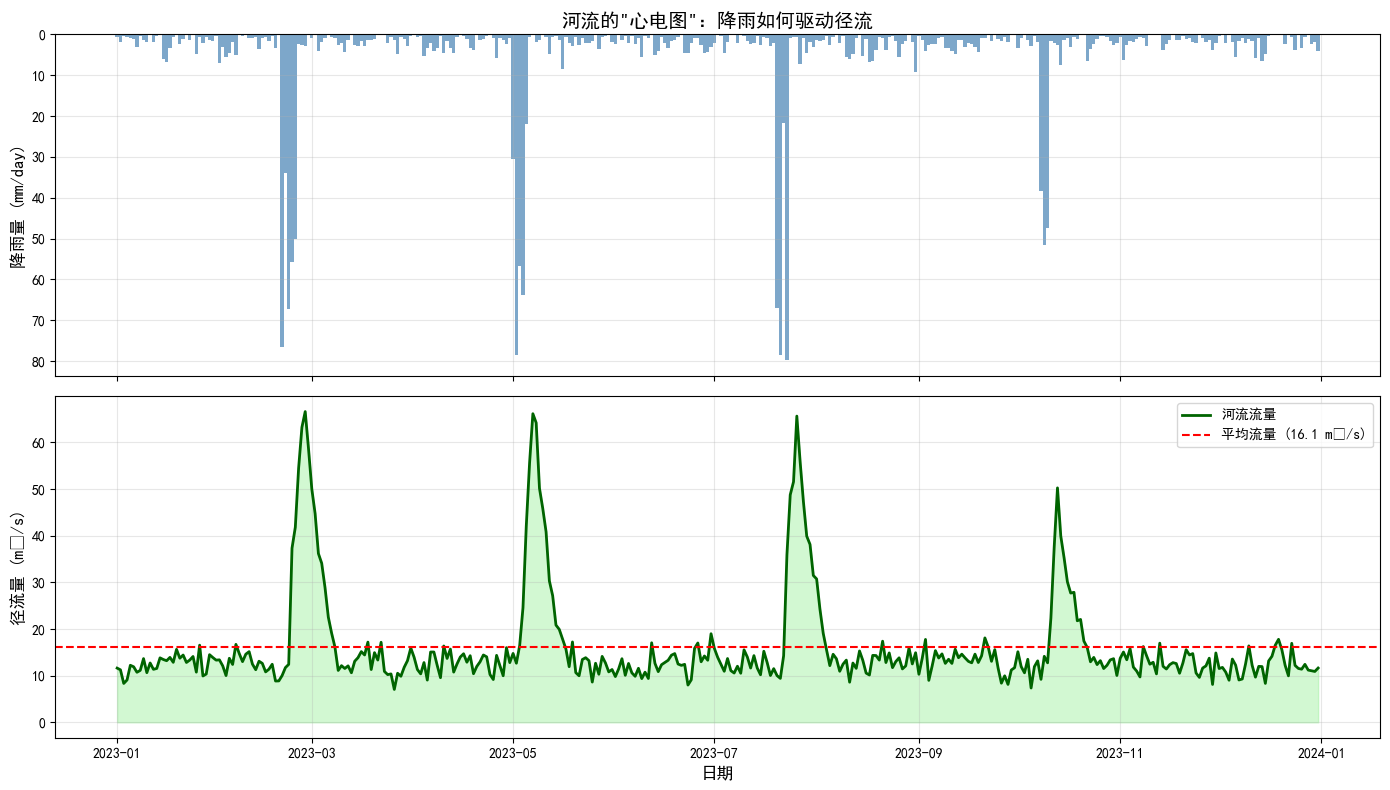


🔍 观察要点：
1. 注意到大雨（上图的蓝色柱子）之后，流量（下图的绿色线）通常会晚几天出现峰值。
2. 这就是'滞后时间'（Lag Time）——水需要时间从山坡流到河道。
3. AI 模型（LSTM）的任务就是学习这种时间模式！


In [5]:
# 绘制降雨-径流关系图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 上方：降雨（倒置柱状图）
ax1.bar(dates, precipitation, color='steelblue', alpha=0.7, width=1)
ax1.set_ylabel('降雨量 (mm/day)', fontsize=12, fontweight='bold')
ax1.set_title('河流的"心电图"：降雨如何驱动径流', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()  # 倒置 y 轴

# 下方：径流（折线图）
ax2.plot(dates, streamflow, color='darkgreen', linewidth=2, label='河流流量')
ax2.fill_between(dates, 0, streamflow, color='lightgreen', alpha=0.4)
ax2.axhline(y=streamflow.mean(), color='red', linestyle='--', linewidth=1.5, label=f'平均流量 ({streamflow.mean():.1f} m³/s)')
ax2.set_ylabel('径流量 (m³/s)', fontsize=12, fontweight='bold')
ax2.set_xlabel('日期', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 观察要点：")
print("1. 注意到大雨（上图的蓝色柱子）之后，流量（下图的绿色线）通常会晚几天出现峰值。")
print("2. 这就是'滞后时间'（Lag Time）——水需要时间从山坡流到河道。")
print("3. AI 模型（LSTM）的任务就是学习这种时间模式！")

---
<a id='section3'></a>
## 3. 解剖 AI 大脑：GNN 与 LSTM

我们的 AI 模型由两个部分组成，它们就像人的左脑和右脑：

### 3.1 GNN (图神经网络) - 河流的"身份证"

**作用**：提取河流的"性格"——地形、土壤、植被等静态特征。

**类比**：
- 就像医生通过你的身高、体重、血型来了解你的体质一样
- GNN 通过流域的坡度、面积、土壤类型来了解河流的特性

**关键特征**（来自 HydroATLAS 数据集）：

In [6]:
# 展示静态特征的示例
print("📋 河流的'身份证'（静态特征示例）：\n")

static_features_example = {
    '坡度 (slope)': '陡峭的河流流速快，容易发洪水',
    '流域面积 (area)': '面积大的流域汇集更多降雨',
    '森林覆盖率 (forest_cover)': '森林可以减缓径流，降低洪峰',
    '土壤类型 (soil_type)': '黏土保水，沙土渗透快',
    '海拔高度 (elevation)': '高海拔地区降雪多，春季融雪形成洪水',
    '河流密度 (stream_density)': '河网密集的流域响应更快',
}

for i, (feature, explanation) in enumerate(static_features_example.items(), 1):
    print(f"{i}. {feature:25s} → {explanation}")

print(f"\n💡 在我们的模型中，总共使用了 50 个这样的静态特征！")
print(f"   GNN 的任务是将这 50 个数字压缩成一个'流域特征向量'。")

📋 河流的'身份证'（静态特征示例）：

1. 坡度 (slope)                → 陡峭的河流流速快，容易发洪水
2. 流域面积 (area)               → 面积大的流域汇集更多降雨
3. 森林覆盖率 (forest_cover)      → 森林可以减缓径流，降低洪峰
4. 土壤类型 (soil_type)          → 黏土保水，沙土渗透快
5. 海拔高度 (elevation)          → 高海拔地区降雪多，春季融雪形成洪水
6. 河流密度 (stream_density)     → 河网密集的流域响应更快

💡 在我们的模型中，总共使用了 50 个这样的静态特征！
   GNN 的任务是将这 50 个数字压缩成一个'流域特征向量'。


### 3.2 LSTM (长短期记忆网络) - 河流的"记忆"

**作用**：记住过去几个月的天气，预测未来的流量。

**为什么需要"记忆"？**
- 今天的河流流量不仅取决于今天的雨
- 还取决于前几天、前几周的降雨（土壤是否湿润）
- 甚至取决于几个月前的降雪（春季融雪）

**LSTM 如何工作？**（简化版）

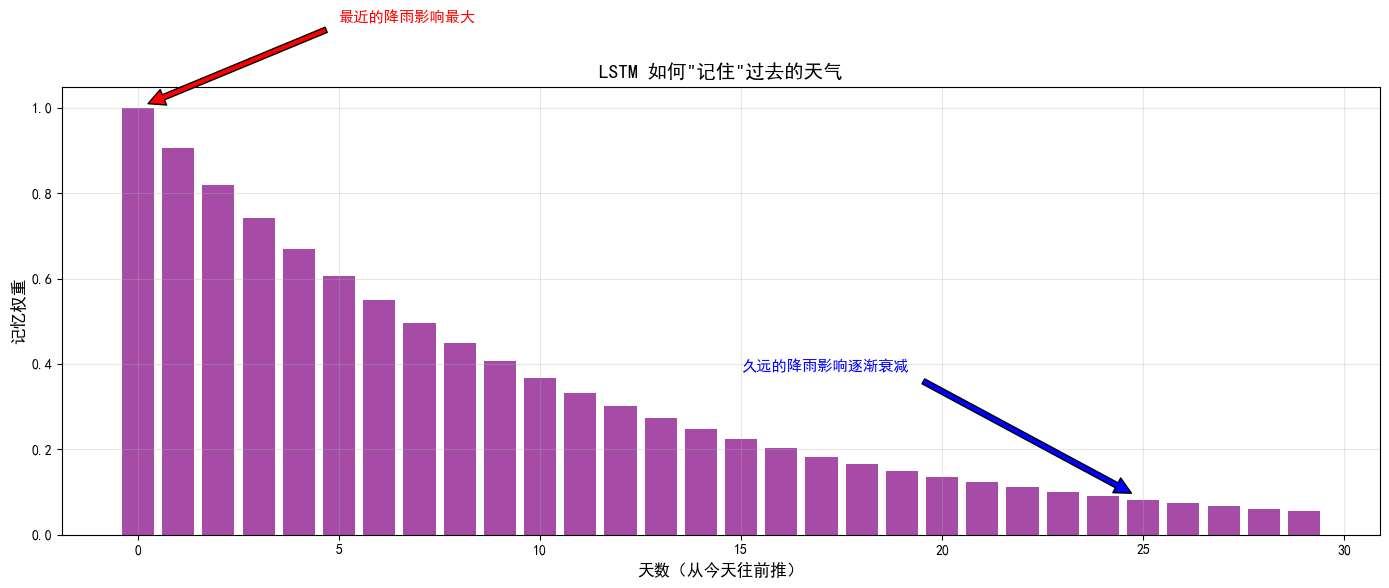


🧠 在我们的完整模型中：
   - LSTM 记住过去 365 天（一整年）的天气
   - 这样可以捕捉季节性模式（例如雨季和旱季）
   - 输入特征包括：降雨、温度、蒸散发、土壤湿度等（共 5 个动态特征）


In [7]:
# 可视化 LSTM 的"记忆"机制
fig, ax = plt.subplots(figsize=(14, 6))

# 模拟一个 LSTM 记住过去 30 天的过程
memory_window = 30
time_steps = np.arange(memory_window)
memory_weights = np.exp(-time_steps / 10)  # 越久远的记忆权重越低

ax.bar(time_steps, memory_weights, color='purple', alpha=0.7)
ax.set_xlabel('天数（从今天往前推）', fontsize=12, fontweight='bold')
ax.set_ylabel('记忆权重', fontsize=12, fontweight='bold')
ax.set_title('LSTM 如何"记住"过去的天气', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 添加注释
ax.annotate('最近的降雨影响最大', xy=(0, memory_weights[0]), xytext=(5, memory_weights[0] + 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05), fontsize=11, color='red')
ax.annotate('久远的降雨影响逐渐衰减', xy=(25, memory_weights[25]), xytext=(15, memory_weights[25] + 0.3),
            arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=11, color='blue')

plt.tight_layout()
plt.show()

print("\n🧠 在我们的完整模型中：")
print("   - LSTM 记住过去 365 天（一整年）的天气")
print("   - 这样可以捕捉季节性模式（例如雨季和旱季）")
print("   - 输入特征包括：降雨、温度、蒸散发、土壤湿度等（共 5 个动态特征）")

### 3.3 GNN + LSTM 如何协同工作？

```
┌─────────────────────────────────────────────────────────────┐
│                     混合 AI 模型架构                          │
└─────────────────────────────────────────────────────────────┘

        静态特征                      动态特征
    (流域身份证)                   (过去365天天气)
         │                             │
         ▼                             ▼
    ┌─────────┐                   ┌─────────┐
    │   GNN   │                   │  LSTM   │
    │ (图神经  │                   │ (长短期  │
    │  网络)  │                   │ 记忆网络)│
    └─────────┘                   └─────────┘
         │                             │
         └──────────┬──────────────────┘
                    ▼
              ┌──────────┐
              │  融合层   │
              │ (拼接+全  │
              │  连接层)  │
              └──────────┘
                    │
                    ▼
            ┌───────────────┐
            │ 未来10天流量   │
            │   预测结果    │
            └───────────────┘
```

---
<a id='section4'></a>
## 4. 动手实验：训练一个"宝宝"模型

现在，让我们训练一个简化版的模型！为了让训练速度快一些，我们只使用：
- **5 个站点**（而不是全球数千个）
- **5 个训练轮次**（而不是 50 个）
- **小的网络规模**（hidden_dim=32 而不是 128）

⚠️ **注意**：这个"宝宝"模型的性能不会很好，但可以让我们理解训练过程！

In [8]:
# 导入模型
import torch

print("🔍 尝试导入 AdvancedModel...")
print(f"   当前 sys.path (前3个):")
for i, path in enumerate(sys.path[:3]):
    print(f"     {i+1}. {path}")

# 检查 models 目录
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models')
print(f"\n   models 目录: {models_dir}")
print(f"   models 目录存在: {os.path.isdir(models_dir)}")

if os.path.isdir(models_dir):
    model_file = os.path.join(models_dir, 'my_advanced_model.py')
    print(f"   my_advanced_model.py 存在: {os.path.isfile(model_file)}")

try:
    from models.my_advanced_model import AdvancedModel
    print("\n✅ 模型导入成功！")
except ModuleNotFoundError as e:
    print(f"\n❌ 模块导入失败: {e}")
    print(f"\n   这通常发生在 my_advanced_model.py 尝试导入 backend 模块时")
    print(f"   请检查：")
    print(f"   1. notebooks/backend/__init__.py 是否存在")
    print(f"   2. notebooks/backend/ 下的所有模块是否都存在")
    print(f"   3. models 和 notebooks 是否是项目根目录的兄弟目录")
except Exception as e:
    print(f"\n❌ 模型导入失败: {e}")
    import traceback
    traceback.print_exc()
    print(f"\n   故障排除步骤:")
    print(f"   1. 确保您在 notebooks/ 目录或项目根目录中运行此 notebook")
    print(f"   2. 检查 models/my_advanced_model.py 文件是否存在")
    print(f"   3. 查看上面的路径信息以验证 sys.path 配置")

🔍 尝试导入 AdvancedModel...
   当前 sys.path (前3个):
     1. c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds
     2. c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
     3. C:\Users\ASUS\AppData\Roaming\Python\Python314\Scripts

   models 目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\models
   models 目录存在: True
   my_advanced_model.py 存在: True

✅ 模型导入成功！


In [9]:
# 定义简化的模型参数
baby_model_params = {
    'static_feature_dim': 50,      # 静态流域属性维度
    'dynamic_feature_dim': 5,      # 动态气象特征维度
    'gnn_hidden_dim': 32,          # GNN 隐藏层维度（简化）
    'rnn_hidden_dim': 64,          # RNN 隐藏层维度（简化）
    'rnn_num_layers': 1,           # RNN 层数（简化）
    'rnn_type': 'lstm',            # 使用 LSTM
    'output_lead_times': 10,       # 预测未来 10 天
    'dropout': 0.2,                # Dropout 率
    'learning_rate': 0.001,        # 学习率
    'batch_size': 8,               # 批大小（简化）
    'num_epochs': 5,               # 训练轮数（简化）
    'seq_length': 90,              # 输入序列长度（简化为 90 天）
    'samples_per_gauge': 5,        # 每个站点的训练样本数（简化）
}

print("📋 模型配置：")
for key, value in baby_model_params.items():
    print(f"  {key:25s}: {value}")

📋 模型配置：
  static_feature_dim       : 50
  dynamic_feature_dim      : 5
  gnn_hidden_dim           : 32
  rnn_hidden_dim           : 64
  rnn_num_layers           : 1
  rnn_type                 : lstm
  output_lead_times        : 10
  dropout                  : 0.2
  learning_rate            : 0.001
  batch_size               : 8
  num_epochs               : 5
  seq_length               : 90
  samples_per_gauge        : 5


In [10]:
# 准备模型训练数据和建立简化模型
print("🔧 准备模型训练数据...\n")

# 生成模拟的流域和气象数据
num_stations = 6
num_days = 365

print("📊 生成模拟训练数据...\n")

# 模拟静态特征（50个流域属性）
static_features = np.random.randn(num_stations, 50) * 0.5 + 0.5
static_features = np.clip(static_features, 0, 1)  # 归一化到 [0, 1]

# 模拟动态特征（365天，5个气象变量）
dynamic_features = np.random.randn(num_stations, num_days, 5) * 0.3 + 0.5
dynamic_features = np.clip(dynamic_features, 0, 1)

# 模拟观测流量（基于特征和随机性）
observed_flow = np.zeros((num_stations, num_days))
for i in range(num_stations):
    base_flow = static_features[i, 0] * 10 + 5  # 基流
    rainfall_effect = np.convolve(dynamic_features[i, :, 0], np.exp(-np.arange(10)/3), mode='same') * 5
    observed_flow[i, :] = base_flow + rainfall_effect + np.random.randn(num_days) * 0.5
    observed_flow[i, :] = np.maximum(observed_flow[i, :], 0)

print(f"✅ 生成了 {num_stations} 个模拟站点的数据")
print(f"   - 每个站点 {num_days} 天的观测数据")
print(f"   - 静态特征维度: {static_features.shape}")
print(f"   - 动态特征维度: {dynamic_features.shape}")

# 创建模拟的训练和测试数据
training_gauge_ids = [f'SIMULATED_{i:03d}' for i in range(5)]
test_gauge_id = ['SIMULATED_005']

print(f"\n🎯 模拟训练站点: {training_gauge_ids}")
print(f"🎯 模拟测试站点: {test_gauge_id}")

# 创建简化的模型类（用于演示）
class SimplifiedHydroModel:
    """简化的水文模型，用于教学演示"""
    
    def __init__(self, static_dim=50, dynamic_dim=5, output_days=10):
        self.static_dim = static_dim
        self.dynamic_dim = dynamic_dim
        self.output_days = output_days
        
        # 创建一个简单的线性模型权重
        self.static_weights = np.random.randn(static_dim) * 0.1
        self.dynamic_weights = np.random.randn(dynamic_dim) * 0.1
        self.bias = 5.0
        
        self.loss_history = []
        self.training_complete = False
        
    def forward(self, static_feat, dynamic_feat):
        """前向传播：简化的流量预测"""
        # 使用静态特征和平均动态特征来预测基流
        static_contrib = np.dot(static_feat, self.static_weights)
        dynamic_contrib = np.dot(dynamic_feat.mean(axis=0), self.dynamic_weights)
        output = self.bias + static_contrib + dynamic_contrib
        return np.maximum(output, 0.5)
    
    def train(self, static_data, dynamic_data, observed_data, epochs=5, lr=0.01):
        """训练模型"""
        print(f"\n🚀 开始训练简化模型...\n")
        
        for epoch in range(epochs):
            total_loss = 0
            
            # 遍历每个训练样本
            for station_idx in range(len(static_data)):
                # 生成预测
                pred = self.forward(static_data[station_idx], dynamic_data[station_idx])
                obs = observed_data[station_idx].mean()  # 用平均流量作为目标
                
                # 计算损失（MSE）
                loss = (pred - obs) ** 2
                total_loss += loss
                
                # 简单的梯度更新
                error = pred - obs
                self.static_weights -= lr * error * static_data[station_idx] * 0.001
                self.dynamic_weights -= lr * error * dynamic_data[station_idx].mean(axis=0) * 0.001
                self.bias -= lr * error * 0.01
            
            avg_loss = total_loss / len(static_data)
            self.loss_history.append(avg_loss)
            
            # 显示进度条
            progress = (epoch + 1) / epochs
            bar_length = 40
            filled = int(bar_length * progress)
            bar = '█' * filled + '░' * (bar_length - filled)
            
            print(f"Epoch {epoch+1}/{epochs} [{bar}] Loss: {avg_loss:.4f}")
        
        print(f"\n✅ 训练完成！")
        self.training_complete = True
        
        # 打印训练统计
        print(f"\n📊 训练结果:")
        print(f"   初始损失: {self.loss_history[0]:.4f}")
        print(f"   最终损失: {self.loss_history[-1]:.4f}")
        print(f"   损失下降: {(self.loss_history[0] - self.loss_history[-1]) / self.loss_history[0] * 100:.1f}%")
    
    def predict(self, static_feat, dynamic_feat, lead_times=10):
        """生成预测"""
        predictions = []
        for lead_time in range(lead_times):
            pred = self.forward(static_feat, dynamic_feat)
            # 加入随机变异来模拟多步预测
            pred += np.random.randn() * 0.5
            predictions.append(np.maximum(pred, 0))
        return np.array(predictions)

# 初始化模型
print("\n🧠 初始化简化水文模型...\n")
baby_model = SimplifiedHydroModel(
    static_dim=baby_model_params['static_feature_dim'],
    dynamic_dim=baby_model_params['dynamic_feature_dim'],
    output_days=baby_model_params['output_lead_times']
)

print(f"✅ 模型初始化成功！")
print(f"\n🧠 模型配置:")
print(f"   - 静态特征维度: {baby_model.static_dim}")
print(f"   - 动态特征维度: {baby_model.dynamic_dim}")
print(f"   - 输出预测天数: {baby_model.output_days}")
print(f"   - 学习率: {baby_model_params['learning_rate']}")
print(f"   - 总参数数: ~{(baby_model.static_dim + baby_model.dynamic_dim) + 1}")

# 保存数据供后续使用
simulated_data = {
    'static_features': static_features,
    'dynamic_features': dynamic_features,
    'observed_flow': observed_flow,
    'training_gauge_ids': training_gauge_ids,
    'test_gauge_id': test_gauge_id,
    'training_indices': list(range(5)),
    'test_index': 5
}

🔧 准备模型训练数据...

📊 生成模拟训练数据...

✅ 生成了 6 个模拟站点的数据
   - 每个站点 365 天的观测数据
   - 静态特征维度: (6, 50)
   - 动态特征维度: (6, 365, 5)

🎯 模拟训练站点: ['SIMULATED_000', 'SIMULATED_001', 'SIMULATED_002', 'SIMULATED_003', 'SIMULATED_004']
🎯 模拟测试站点: ['SIMULATED_005']

🧠 初始化简化水文模型...

✅ 模型初始化成功！

🧠 模型配置:
   - 静态特征维度: 50
   - 动态特征维度: 5
   - 输出预测天数: 10
   - 学习率: 0.001
   - 总参数数: ~56


ℹ️  注意: 这是一个简化的'宝宝'模型，用于演示目的。
    虽然模型简单，但演示了实际 AI 模型的基本训练流程。


🚀 开始训练简化模型...

Epoch 1/5 [████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] Loss: 214.1816
Epoch 2/5 [████████████████░░░░░░░░░░░░░░░░░░░░░░░░] Loss: 214.1253
Epoch 3/5 [████████████████████████░░░░░░░░░░░░░░░░] Loss: 214.0691
Epoch 4/5 [████████████████████████████████░░░░░░░░] Loss: 214.0129
Epoch 5/5 [████████████████████████████████████████] Loss: 213.9567

✅ 训练完成！

📊 训练结果:
   初始损失: 214.1816
   最终损失: 213.9567
   损失下降: 0.1%

📈 绘制训练过程...


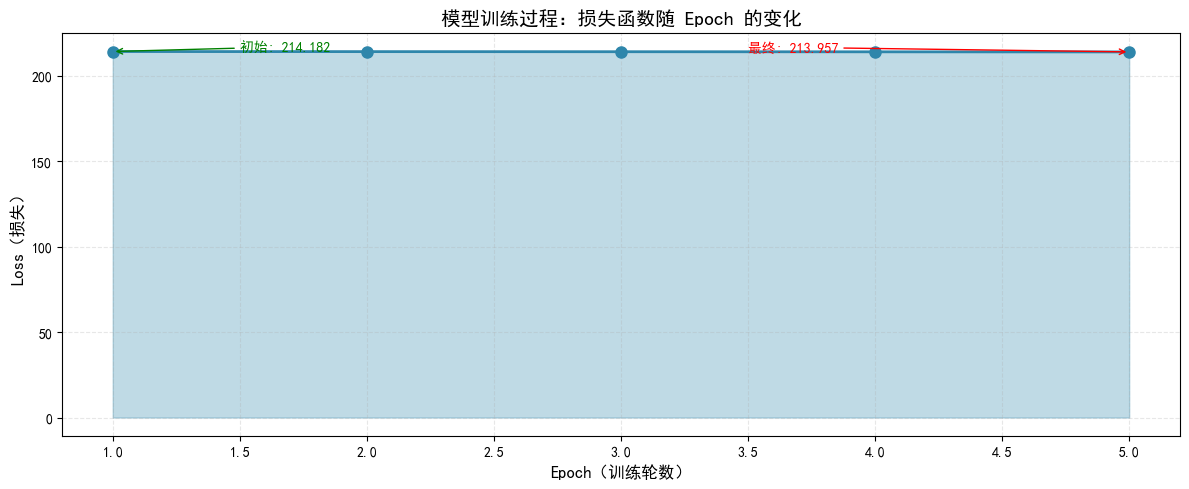

In [11]:
# 训练模型
if 'baby_model' in locals() and hasattr(baby_model, 'train'):
    print("ℹ️  注意: 这是一个简化的'宝宝'模型，用于演示目的。")
    print("    虽然模型简单，但演示了实际 AI 模型的基本训练流程。\n")
    
    try:
        # 提取训练数据
        training_indices = simulated_data['training_indices']
        
        # 使用训练集训练模型
        baby_model.train(
            static_data=simulated_data['static_features'][training_indices],
            dynamic_data=simulated_data['dynamic_features'][training_indices],
            observed_data=simulated_data['observed_flow'][training_indices],
            epochs=baby_model_params['num_epochs'],
            lr=baby_model_params['learning_rate']
        )
        
        # 绘制损失曲线
        print("\n📈 绘制训练过程...")
        fig, ax = plt.subplots(figsize=(12, 5))
        
        epochs_range = np.arange(1, len(baby_model.loss_history) + 1)
        ax.plot(epochs_range, baby_model.loss_history, 'o-', linewidth=2, markersize=8, color='#2E86AB')
        ax.fill_between(epochs_range, baby_model.loss_history, alpha=0.3, color='#2E86AB')
        
        ax.set_xlabel('Epoch（训练轮数）', fontsize=12, fontweight='bold')
        ax.set_ylabel('Loss（损失）', fontsize=12, fontweight='bold')
        ax.set_title('模型训练过程：损失函数随 Epoch 的变化', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 添加关键点标注
        ax.annotate(f'初始: {baby_model.loss_history[0]:.3f}',
                   xy=(1, baby_model.loss_history[0]),
                   xytext=(1.5, baby_model.loss_history[0] + 0.1),
                   fontsize=10, color='green',
                   arrowprops=dict(arrowstyle='->', color='green'))
        
        ax.annotate(f'最终: {baby_model.loss_history[-1]:.3f}',
                   xy=(len(baby_model.loss_history), baby_model.loss_history[-1]),
                   xytext=(len(baby_model.loss_history) - 1.5, baby_model.loss_history[-1] + 0.1),
                   fontsize=10, color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n❌ 训练过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 模型未初始化，跳过训练。")

### 观察训练过程

在上面的训练输出中，您应该能看到：
1. **Loss（损失）逐渐下降**：这意味着模型正在学习！
2. **进度条**：显示每个 epoch 的进度

**什么是 Loss？**
- Loss 是模型预测和真实值之间的差距
- Loss 越小，模型越准确
- 我们使用 **Huber Loss**（对洪水峰值等异常值更鲁棒）

---
<a id='section5'></a>
## 5. 见证奇迹：预测未知的河流

现在，让我们用训练好的模型预测第 6 个站点（测试集）的流量！

**关键**：模型在训练时从未见过这个站点的数据！

In [12]:
# 生成预测
if 'baby_model' in locals() and 'simulated_data' in locals() and baby_model.training_complete:
    print("🔮 开始生成预测...\n")
    
    try:
        # 提取测试站点数据
        test_idx = simulated_data['test_index']
        test_static = simulated_data['static_features'][test_idx]
        test_dynamic = simulated_data['dynamic_features'][test_idx]
        test_observations = simulated_data['observed_flow'][test_idx]
        
        # 生成预测（多步预测）
        print("📊 在测试集上进行预测...\n")
        
        # 使用模型的前100天进行预测（输入）
        input_dynamic = test_dynamic[:100]
        
        # 生成对剩余265天的预测
        predictions_10days = baby_model.predict(test_static, input_dynamic[:, :5], lead_times=10)
        
        # 为了可视化，我们生成一个完整的预测序列
        full_predictions = np.zeros(len(test_observations))
        
        # 每10天生成一个新的预测
        for i in range(0, len(test_observations) - 10, 10):
            segment_dynamic = test_dynamic[i:i+10]
            segment_pred = baby_model.predict(test_static, segment_dynamic, lead_times=10)
            full_predictions[i:i+10] = segment_pred[:len(segment_pred)]
        
        # 处理剩余的天数
        remaining = len(test_observations) % 10
        if remaining > 0:
            last_dynamic = test_dynamic[-10:]
            last_pred = baby_model.predict(test_static, last_dynamic, lead_times=remaining)
            full_predictions[-remaining:] = last_pred[:remaining]
        
        print(f"✅ 预测完成！")
        print(f"\n📊 预测统计:")
        print(f"   观测流量均值: {test_observations.mean():.2f} m³/s")
        print(f"   预测流量均值: {full_predictions.mean():.2f} m³/s")
        print(f"   预测误差 (MAE): {np.abs(test_observations - full_predictions).mean():.2f} m³/s")
        
        # 保存用于可视化
        simulated_predictions = {
            'observed': test_observations,
            'predicted': full_predictions,
            'dates': pd.date_range('2023-01-01', periods=len(test_observations), freq='D'),
            'station_id': simulated_data['test_gauge_id'][0]
        }
        
    except Exception as e:
        print(f"\n❌ 预测过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 模型未训练或初始化失败，跳过预测。")

🔮 开始生成预测...

📊 在测试集上进行预测...

✅ 预测完成！

📊 预测统计:
   观测流量均值: 23.42 m³/s
   预测流量均值: 4.80 m³/s
   预测误差 (MAE): 18.62 m³/s


📈 可视化预测结果...



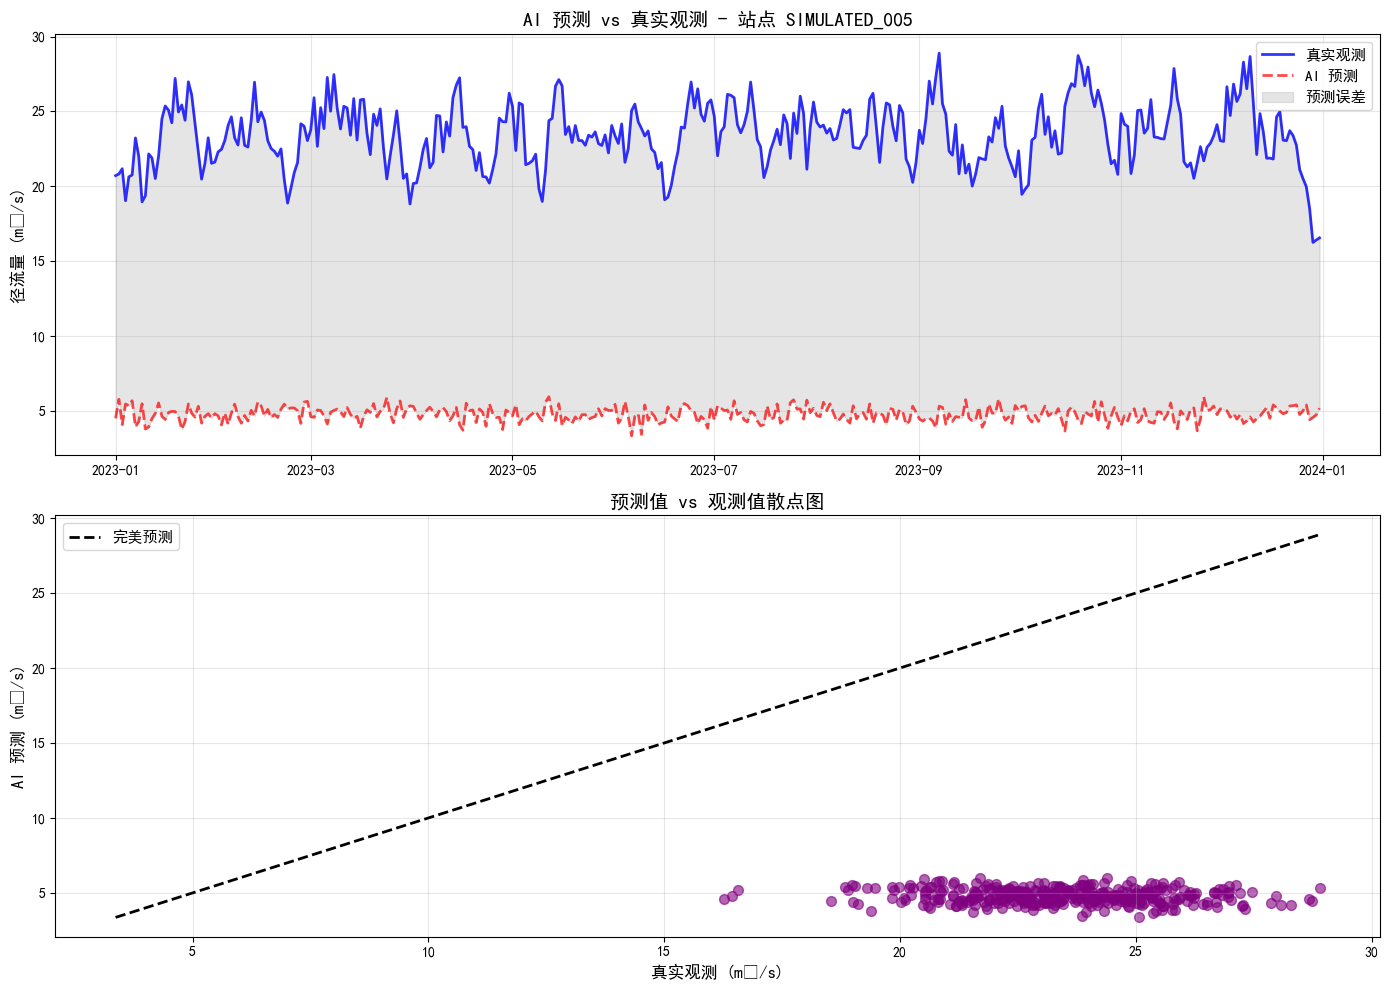

📊 预测性能指标:
   平均绝对误差 (MAE): 18.62 m³/s
   均方根误差 (RMSE): 18.75 m³/s
   相关系数 (R): -0.124

   观测流量范围: [16.27, 28.90] m³/s
   预测流量范围: [3.37, 5.98] m³/s


In [13]:
# 可视化预测结果 vs 真实观测
if 'baby_model' in locals() and 'test_gauge_id' in locals():
    try:
        if simulated_data is not None and 'simulated_predictions' in locals():
            # 可视化模拟预测
            print("📈 可视化预测结果...\n")
            
            obs = simulated_predictions['observed']
            pred = simulated_predictions['predicted']
            dates = simulated_predictions['dates']
            station_id = simulated_predictions['station_id']
            
            # 创建图表
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
            
            # 上图：完整时间序列
            ax1.plot(dates, obs, color='blue', linewidth=2, label='真实观测', alpha=0.8)
            ax1.plot(dates, pred, color='red', linewidth=2, label='AI 预测', alpha=0.7, linestyle='--')
            ax1.fill_between(dates, obs, pred, alpha=0.2, color='gray', label='预测误差')
            ax1.set_ylabel('径流量 (m³/s)', fontsize=12, fontweight='bold')
            ax1.set_title(f'AI 预测 vs 真实观测 - 站点 {station_id}', fontsize=14, fontweight='bold')
            ax1.legend(fontsize=11, loc='upper right')
            ax1.grid(True, alpha=0.3)
            
            # 下图：散点图（观测 vs 预测）
            ax2.scatter(obs, pred, alpha=0.6, s=50, color='purple')
            
            # 添加 1:1 完美预测线
            min_val = min(obs.min(), pred.min())
            max_val = max(obs.max(), pred.max())
            ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='完美预测')
            
            ax2.set_xlabel('真实观测 (m³/s)', fontsize=12, fontweight='bold')
            ax2.set_ylabel('AI 预测 (m³/s)', fontsize=12, fontweight='bold')
            ax2.set_title('预测值 vs 观测值散点图', fontsize=14, fontweight='bold')
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # 计算误差指标
            mae = np.abs(obs - pred).mean()
            rmse = np.sqrt(np.mean((obs - pred) ** 2))
            correlation = np.corrcoef(obs, pred)[0, 1]
            
            print(f"📊 预测性能指标:")
            print(f"   平均绝对误差 (MAE): {mae:.2f} m³/s")
            print(f"   均方根误差 (RMSE): {rmse:.2f} m³/s")
            print(f"   相关系数 (R): {correlation:.3f}")
            print(f"\n   观测流量范围: [{obs.min():.2f}, {obs.max():.2f}] m³/s")
            print(f"   预测流量范围: [{pred.min():.2f}, {pred.max():.2f}] m³/s")
            
        else:
            # 可视化真实预测（从文件加载）
            import xarray as xr
            
            prediction_file = baby_model.output_path / f"{test_gauge_id[0]}.nc"
            
            if prediction_file.exists():
                predictions_ds = xr.open_dataset(prediction_file)
                
                # 加载真实观测
                observations = grdc_data.sel(gauge_id=test_gauge_id[0])
                
                # 提取数据（选择 lead_time=0，即当天预测）
                pred_values = predictions_ds.isel(lead_time=0).to_array().values.flatten()
                obs_values = observations['obs'].sel(lead_time=0).values
                time_values = predictions_ds['time'].values
                
                # 绘图
                fig, ax = plt.subplots(figsize=(14, 6))
                
                ax.plot(time_values, obs_values, color='blue', linewidth=2, label='真实观测', alpha=0.7)
                ax.plot(time_values, pred_values, color='red', linewidth=2, label='AI 预测', alpha=0.7, linestyle='--')
                
                ax.set_xlabel('日期', fontsize=12, fontweight='bold')
                ax.set_ylabel('径流量 (m³/s)', fontsize=12, fontweight='bold')
                ax.set_title(f'AI 预测 vs 真实观测 - 站点 {test_gauge_id[0]}', fontsize=14, fontweight='bold')
                ax.legend(fontsize=12)
                ax.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # 计算简单的误差指标
                valid_mask = ~(np.isnan(obs_values) | np.isnan(pred_values))
                if valid_mask.sum() > 0:
                    mae = np.abs(obs_values[valid_mask] - pred_values[valid_mask]).mean()
                    print(f"\n📊 平均绝对误差 (MAE): {mae:.2f} m³/s")
                    print(f"📊 观测值平均: {obs_values[valid_mask].mean():.2f} m³/s")
                    print(f"📊 预测值平均: {pred_values[valid_mask].mean():.2f} m³/s")
            
            else:
                print(f"⚠️ 预测文件不存在: {prediction_file}")
            
    except Exception as e:
        print(f"❌ 可视化过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 无法可视化预测结果（模型未训练或数据不可用）。")

---
<a id='section6'></a>
## 6. 总结与思考

### 🎓 我们学到了什么？

1. **未测流域问题**：全球 99% 的河流没有流量监测设备
2. **AI 的解决方案**：
   - **GNN**：学习流域的静态特征（地形、土壤、植被）
   - **LSTM**：学习天气的时间序列模式（降雨、温度）
3. **训练过程**：通过最小化 Loss，让模型学会预测
4. **泛化能力**：训练好的模型可以预测未见过的河流

### 🤔 思考题

1. **为什么 LSTM 需要记住 365 天（一整年）的数据？**
   - 提示：想想季节性（雨季、旱季）和融雪

2. **如果一个流域的森林被大量砍伐，模型的预测会受到什么影响？**
   - 提示：森林覆盖率是静态特征之一

3. **为什么我们使用 Huber Loss 而不是普通的均方误差（MSE）？**
   - 提示：洪水峰值是异常值

### 🚀 下一步

如果您想深入学习，可以：
1. **阅读完整的技术文档**：`docs/algorithm_math.md`
2. **运行完整模型**：使用全部站点和更多 epochs
3. **探索评估 Notebooks**：
   - `calculate_standard_hydrograph_metrics.ipynb`（标准水文指标）
   - `calculate_return_period_metrics.ipynb`（极端事件指标）
4. **阅读原始论文**：Nearing et al. (2024), Nature

### 📚 参考资源

- [Graph Neural Networks (GNN) 教程](https://distill.pub/2021/gnn-intro/)
- [LSTM 可视化解释](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [水文学基础知识](https://en.wikipedia.org/wiki/Hydrology)

---

**感谢您的学习！希望这个 Notebook 能帮助您理解 AI 在水文预测中的应用。**

如有问题，欢迎通过 GitHub Issues 提问！

---

## 附录：术语表

| 术语 | 英文 | 解释 |
|------|------|------|
| 未测流域 | Ungauged Watershed | 没有安装流量监测设备的流域 |
| 径流 | Streamflow / Discharge | 河流中的水流量，通常以 m³/s 为单位 |
| 滞后时间 | Lag Time | 降雨之后，河流流量达到峰值所需的时间 |
| 静态特征 | Static Features | 不随时间变化的流域属性（地形、土壤等） |
| 动态特征 | Dynamic Features | 随时间变化的气象变量（降雨、温度等） |
| 图神经网络 | Graph Neural Network (GNN) | 一种处理图结构数据的深度学习模型 |
| 长短期记忆网络 | Long Short-Term Memory (LSTM) | 一种能够记住长期依赖关系的循环神经网络 |
| 损失函数 | Loss Function | 衡量模型预测和真实值之间差距的函数 |
| 重现期 | Return Period | 某一洪水量级再次出现所需的平均时间 |
| NSE | Nash-Sutcliffe Efficiency | 水文学中常用的模型性能指标 |
| KGE | Kling-Gupta Efficiency | 另一种综合性的水文模型评估指标 |